In [177]:
import pandas as pd
import glob
import numpy as np

file_paths = glob.glob('20*.csv')

df_list = []

for file in file_paths:
    temp_df = pd.read_csv(file, encoding="cp949")  # 또는 utf-8-sig
    df_list.append(temp_df)

df = pd.concat(df_list,ignore_index = True)

df.info()

C:\Users\j2h09\AppData\Local\Temp\ipykernel_14680\906493639.py:10: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file, encoding="cp949")  # 또는 utf-8-sig
C:\Users\j2h09\AppData\Local\Temp\ipykernel_14680\906493639.py:10: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file, encoding="cp949")  # 또는 utf-8-sig
C:\Users\j2h09\AppData\Local\Temp\ipykernel_14680\906493639.py:10: DtypeWarning: Columns (7,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file, encoding="cp949")  # 또는 utf-8-sig
C:\Users\j2h09\AppData\Local\Temp\ipykernel_14680\906493639.py:10: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  temp_df = pd.read_csv(file, encoding="cp949")  # 또는 utf-8-sig


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833614 entries, 0 to 833613
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   접수연도              833614 non-null  int64  
 1   자치구코드             833614 non-null  int64  
 2   자치구명              833613 non-null  object 
 3   법정동코드             833614 non-null  int64  
 4   법정동명              833614 non-null  object 
 5   지번구분              776043 non-null  float64
 6   지번구분명             776043 non-null  object 
 7   본번                776052 non-null  object 
 8   부번                776052 non-null  object 
 9   건물명               776065 non-null  object 
 10  계약일               833614 non-null  int64  
 11  물건금액(만원)          833614 non-null  int64  
 12  건물면적(㎡)           833614 non-null  float64
 13  토지면적(㎡)           668824 non-null  float64
 14  층                 776119 non-null  float64
 15  권리구분              7614 non-null    object 
 16  취소일               25

In [178]:
df2 = df.copy()

In [179]:
df2["자치구명"] = df2["자치구명"].astype("string")
df2["자치구명"].unique()

df2["법정동명"] = df2["법정동명"].astype("string")
df2["법정동명"].unique()

df2["지번구분"] = df2["지번구분"].fillna(0).astype('int64')
df2["지번구분"].unique()

df2["지번구분명"] = df2["지번구분명"].astype("string")
df2["지번구분명"].unique()

<StringArray>
['대지', <NA>, '블럭', '산']
Length: 4, dtype: string

In [180]:
# 본번의 형태가 0039, 8.0 같이 섞여 있음.
# 문자열로 통일하여 공백, 빈 값 정리
df2["본번"] = df2["본번"].astype("string").str.strip()
df2["본번"] = df2["본번"].replace("",pd.NA)

# 숫자처럼 보이면 숫자, 아니면 NaN -> int로 변환
num = pd.to_numeric(df2["본번"],errors = "coerce")
num = num.fillna(0).astype("int64")

df2["본번"] = num
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833614 entries, 0 to 833613
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   접수연도              833614 non-null  int64  
 1   자치구코드             833614 non-null  int64  
 2   자치구명              833613 non-null  string 
 3   법정동코드             833614 non-null  int64  
 4   법정동명              833614 non-null  string 
 5   지번구분              833614 non-null  int64  
 6   지번구분명             776043 non-null  string 
 7   본번                833614 non-null  int64  
 8   부번                776052 non-null  object 
 9   건물명               776065 non-null  object 
 10  계약일               833614 non-null  int64  
 11  물건금액(만원)          833614 non-null  int64  
 12  건물면적(㎡)           833614 non-null  float64
 13  토지면적(㎡)           668824 non-null  float64
 14  층                 776119 non-null  float64
 15  권리구분              7614 non-null    object 
 16  취소일               25

In [181]:
df2["부번"] = df2["부번"].astype("string").str.strip().str.lstrip("0").replace("0")
df2["부번"] = pd.to_numeric(df2["부번"],errors = "coerce").fillna(0).astype("int64")

df2["건물명"] = df2["건물명"].astype("string").fillna("Unknown")

df2["물건금액(억원)"] = round(df2["물건금액(만원)"] / 10000, 2)

df2["계약일"] = pd.to_datetime(df2["계약일"], format= '%Y%m%d')

df2["토지면적(㎡)"] = df2["토지면적(㎡)"].replace(0.0, np.nan)

# 층이 nan으로 표시되는 것은 임시로 0으로 정리, (df2["층"] == 0).sum()로 봤을 때 0인 값 54289개
df2["층"] = pd.to_numeric(df2["층"], errors = "coerce").fillna(0).astype("int64")

# 건축연도가 비어있는 값은 0으로 채움. (df2["건축년도"] == 0).sum()로 봤을 때 0인 값 10631개
df2["건축년도"] = df2["건축년도"].fillna(0).astype("int64")

df2["건물용도"] = df2["건물용도"].astype("string")

df2 = df2[df2["취소일"].isna()]
df2.info()

C:\Users\j2h09\AppData\Local\Temp\ipykernel_14680\113343379.py:1: FutureWarning: Series.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  df2["부번"] = df2["부번"].astype("string").str.strip().str.lstrip("0").replace("0")


<class 'pandas.core.frame.DataFrame'>
Index: 808073 entries, 0 to 833598
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   접수연도              808073 non-null  int64         
 1   자치구코드             808073 non-null  int64         
 2   자치구명              808072 non-null  string        
 3   법정동코드             808073 non-null  int64         
 4   법정동명              808073 non-null  string        
 5   지번구분              808073 non-null  int64         
 6   지번구분명             753708 non-null  string        
 7   본번                808073 non-null  int64         
 8   부번                808073 non-null  int64         
 9   건물명               808073 non-null  string        
 10  계약일               808073 non-null  datetime64[ns]
 11  물건금액(만원)          808073 non-null  int64         
 12  건물면적(㎡)           808073 non-null  float64       
 13  토지면적(㎡)           423282 non-null  float64       
 14  층        

In [182]:
dfnew = df2[["접수연도","자치구명","법정동명","지번구분","지번구분명","건물명","계약일","물건금액(억원)","건물면적(㎡)","토지면적(㎡)","층","건축년도","건물용도"]]
dfnew.info()

<class 'pandas.core.frame.DataFrame'>
Index: 808073 entries, 0 to 833598
Data columns (total 13 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   접수연도      808073 non-null  int64         
 1   자치구명      808072 non-null  string        
 2   법정동명      808073 non-null  string        
 3   지번구분      808073 non-null  int64         
 4   지번구분명     753708 non-null  string        
 5   건물명       808073 non-null  string        
 6   계약일       808073 non-null  datetime64[ns]
 7   물건금액(억원)  808073 non-null  float64       
 8   건물면적(㎡)   808073 non-null  float64       
 9   토지면적(㎡)   423282 non-null  float64       
 10  층         808073 non-null  int64         
 11  건축년도      808073 non-null  int64         
 12  건물용도      808073 non-null  string        
dtypes: datetime64[ns](1), float64(3), int64(4), string(5)
memory usage: 86.3 MB


In [183]:
dfnew["평수"] = round(dfnew["건물면적(㎡)"] * 0.3025,1)

dfnew["평당단가(억원)"] = round(dfnew["물건금액(억원)"] / dfnew["평수"], 2)

dfnew["계약연도"] = dfnew["계약일"].dt.year
dfnew = dfnew[dfnew["계약연도"] >= 2018]
dfnew["계약월"] = dfnew["계약일"].dt.month
dfnew.info()

C:\Users\j2h09\AppData\Local\Temp\ipykernel_14680\861981439.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfnew["평수"] = round(dfnew["건물면적(㎡)"] * 0.3025,1)
C:\Users\j2h09\AppData\Local\Temp\ipykernel_14680\861981439.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfnew["평당단가(억원)"] = round(dfnew["물건금액(억원)"] / dfnew["평수"], 2)
C:\Users\j2h09\AppData\Local\Temp\ipykernel_14680\861981439.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_

<class 'pandas.core.frame.DataFrame'>
Index: 794628 entries, 0 to 833598
Data columns (total 17 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   접수연도      794628 non-null  int64         
 1   자치구명      794627 non-null  string        
 2   법정동명      794628 non-null  string        
 3   지번구분      794628 non-null  int64         
 4   지번구분명     741441 non-null  string        
 5   건물명       794628 non-null  string        
 6   계약일       794628 non-null  datetime64[ns]
 7   물건금액(억원)  794628 non-null  float64       
 8   건물면적(㎡)   794628 non-null  float64       
 9   토지면적(㎡)   418845 non-null  float64       
 10  층         794628 non-null  int64         
 11  건축년도      794628 non-null  int64         
 12  건물용도      794628 non-null  string        
 13  평수        794628 non-null  float64       
 14  평당단가(억원)  794628 non-null  float64       
 15  계약연도      794628 non-null  int32         
 16  계약월       794628 non-null  int32         
d

In [184]:
dfnew[dfnew["자치구명"].isna()]
dfnew = dfnew[dfnew['자치구명'].notna()]
dfnew.to_csv('cleaned_data.csv', index=False)
dfnew.info()

<class 'pandas.core.frame.DataFrame'>
Index: 794627 entries, 0 to 833598
Data columns (total 17 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   접수연도      794627 non-null  int64         
 1   자치구명      794627 non-null  string        
 2   법정동명      794627 non-null  string        
 3   지번구분      794627 non-null  int64         
 4   지번구분명     741440 non-null  string        
 5   건물명       794627 non-null  string        
 6   계약일       794627 non-null  datetime64[ns]
 7   물건금액(억원)  794627 non-null  float64       
 8   건물면적(㎡)   794627 non-null  float64       
 9   토지면적(㎡)   418845 non-null  float64       
 10  층         794627 non-null  int64         
 11  건축년도      794627 non-null  int64         
 12  건물용도      794627 non-null  string        
 13  평수        794627 non-null  float64       
 14  평당단가(억원)  794627 non-null  float64       
 15  계약연도      794627 non-null  int32         
 16  계약월       794627 non-null  int32         
d

In [185]:
dfnew.describe()

,접수연도,지번구분,계약일,물건금액(억원),건물면적(㎡),토지면적(㎡),층,건축년도,평수,평당단가(억원),계약연도,계약월
count,794627.000000,794627.000000,794627,794627.000000,794627.000000,418845.000000,794627.000000,794627.000000,794627.000000,794627.000000,794627.000000,794627.000000
mean,2020.396506,0.935342,2020-11-03 02:43:27.686877440,6.377757,69.559560,47.526450,6.369432,1976.631510,21.040993,0.304942,2020.357168,6.327847
min,2018.000000,0.000000,2018-01-01 00:00:00,0.170000,5.070000,3.000000,-3.000000,0.000000,1.500000,0.010000,2018.000000,1.000000
25%,2019.000000,1.000000,2019-06-18 00:00:00,2.450000,38.680000,23.000000,2.000000,1993.000000,11.700000,0.180000,2019.000000,4.000000
50%,2020.000000,1.000000,2020-07-15 00:00:00,4.200000,59.400000,30.620000,4.000000,2003.000000,18.000000,0.260000,2020.000000,6.000000
75%,2022.000000,1.000000,2022-01-10 00:00:00,7.980000,84.780000,44.150000,9.000000,2013.000000,25.600000,0.370000,2022.000000,9.000000
max,2024.000000,3.000000,2024-10-14 00:00:00,1108.780000,3619.840000,119119.000000,73.000000,2024.000000,1095.000000,3.280000,2024.000000,12.000000
std,1.872164,0.258559,NaN,7.190257,64.349954,201.182255,5.941284,226.849152,19.466035,0.193597,1.879475,3.280624


In [186]:
# 건물용도별 평당단가 수준 비교 (평균/중위값/거래건수)
df_step1 = dfnew.groupby("건물용도").agg(
        평균평당단가=("평당단가(억원)", "mean"),
        중위평당단가=("평당단가(억원)", "median"),
        거래건수=("평당단가(억원)", "count"),
    ).round(2).sort_values("거래건수", ascending=False)
df_step1

,평균평당단가,중위평당단가,거래건수
건물용도,,,
아파트,0.38,0.33,375782
연립다세대,0.23,0.20,279729
오피스텔,0.26,0.25,86005
단독다가구,0.26,0.19,53111


In [187]:
# 건물용도 x 연도 (용도별 가격 추이)
df_step2 = (dfnew.groupby(["건물용도", "계약연도"]).agg(
        평균평당단가=("평당단가(억원)", "mean"),
        중위평당단가=("평당단가(억원)", "median"),
        거래건수=("평당단가(억원)", "count"),
    )
    .round(2)
    .sort_index()
)


In [188]:
df_step2_pivot = df_step2["중위평당단가"].unstack("계약연도")
df_step2_pivot

계약연도,2018,2019,2020,2021,2022,2023,2024
건물용도,,,,,,,
단독다가구,0.16,0.18,0.19,0.20,0.23,0.22,0.22
아파트,0.23,0.30,0.33,0.40,0.39,0.41,0.44
연립다세대,0.17,0.18,0.19,0.21,0.24,0.24,0.24
오피스텔,0.21,0.22,0.23,0.26,0.28,0.27,0.27


In [189]:
# 용도 x 자치구
df_step3 = (dfnew.groupby(["자치구명", "건물용도"]).agg(
                평균평당단가=("평당단가(억원)", "mean"),
                중위평당단가=("평당단가(억원)", "median"),
                거래건수=("평당단가(억원)", "count"),
            )
            .round(2)
            .sort_index()
)


In [190]:
df_step3_pivot = df_step3_pivot = df_step3["중위평당단가"].unstack("자치구명")
df_step3_pivot

자치구명,강남구,강동구,강북구,강서구,관악구,광진구,구로구,금천구,노원구,도봉구,...,성동구,성북구,송파구,양천구,영등포구,용산구,은평구,종로구,중구,중랑구
건물용도,,,,,,,,,,,,,,,,,,,,,
단독다가구,0.38,0.16,0.14,0.15,0.16,0.18,0.13,0.12,0.15,0.11,...,0.26,0.19,0.19,0.14,0.19,0.39,0.17,0.28,0.32,0.13
아파트,0.71,0.36,0.24,0.30,0.27,0.41,0.24,0.22,0.25,0.21,...,0.46,0.28,0.51,0.34,0.37,0.50,0.27,0.31,0.36,0.23
연립다세대,0.38,0.25,0.14,0.16,0.17,0.23,0.17,0.19,0.15,0.12,...,0.31,0.18,0.25,0.16,0.27,0.32,0.17,0.19,0.24,0.20
오피스텔,0.26,0.21,0.15,0.25,0.22,0.25,0.18,0.28,0.14,0.17,...,0.25,0.18,0.28,0.20,0.24,0.33,0.21,0.27,0.25,0.19


In [191]:
# 건물용도 기준으로 "자치구별 중위평당단가" 연도와 건물용도에 찾고자 하는 물건 넣으면 됨.
gu_by_use = (dfnew[
        (dfnew["계약연도"] == 2024) &
        (dfnew["건물용도"] == "아파트")
    ].
    groupby(["건물용도", "자치구명"])["평당단가(억원)"]
    .median()
    .rename("중위평당단가")
    .reset_index()
)

top5 = gu_by_use.sort_values("중위평당단가", ascending=False).head(5)
bottom5 = gu_by_use.sort_values("중위평당단가", ascending=True).head(5)

In [192]:
top5

,건물용도,자치구명,중위평당단가
14,아파트,서초구,0.92
0,아파트,강남구,0.91
20,아파트,용산구,0.72
17,아파트,송파구,0.64
15,아파트,성동구,0.58


In [193]:
bottom5

,건물용도,자치구명,중위평당단가
9,아파트,도봉구,0.25
7,아파트,금천구,0.27
2,아파트,강북구,0.29
24,아파트,중랑구,0.29
6,아파트,구로구,0.31


In [194]:
# 내가 만들고자 하는 표
# 지역별 건물용도 기준 전년대비 상승률
year_price = (
    dfnew.groupby(["자치구명", "건물용도", "계약연도"])["평당단가(억원)"]
    .median()
    .reset_index()
)

year_price.rename(columns = {"평당단가(억원)": "중위평당단가"}, inplace = True)

year_price.head()

,자치구명,건물용도,계약연도,중위평당단가
0,강남구,단독다가구,2018,0.280
1,강남구,단독다가구,2019,0.280
2,강남구,단독다가구,2020,0.310
3,강남구,단독다가구,2021,0.430
4,강남구,단독다가구,2022,0.465


# 전체 거래량이 연도별로 어떻게 변했는지

In [195]:
COL_REGION = "자치구명"
COL_USE = "건물용도"
COL_YEAR = "계약연도"

base = dfnew[[COL_REGION, COL_USE, COL_YEAR]].copy()

In [196]:
cnt_year = (
    base.groupby(COL_YEAR)
    .size()
    .reset_index(name="거래건수")
    .sort_values(COL_YEAR)
)
cnt_year

,계약연도,거래건수
0,2018,157931
1,2019,141204
2,2020,166894
3,2021,128573
4,2022,60485
5,2023,66822
6,2024,72718


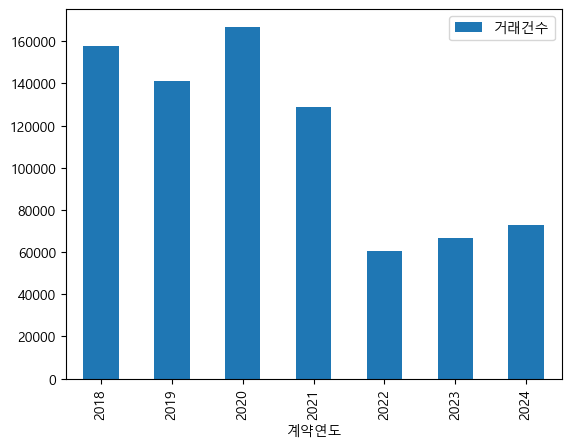

In [197]:
import matplotlib.pyplot as plt
plt.rc("font", family="Malgun Gothic")
ax = cnt_year.plot(x=COL_YEAR, y="거래건수", kind="bar")

# 지역별 거래 집중도

In [198]:
target_year = base[COL_YEAR].max() #---최신연도 기준

cnt_region = (
    base[base[COL_YEAR] == 2024]
    .groupby(COL_REGION)
    .size()
    .reset_index(name = "거래건수")
    .sort_values("거래건수", ascending = False)
)

top10_region = cnt_region.head(10)
top10_region

,자치구명,거래건수
17,송파구,4915
3,강서구,4610
1,강동구,4026
0,강남구,3807
12,마포구,3777
21,은평구,3684
8,노원구,3649
19,영등포구,3301
18,양천구,3282
16,성북구,3244


In [199]:
total = cnt_region["거래건수"].sum()
top10_share = top10_region["거래건수"].sum() / total
top10_share


np.float64(0.5266233944827966)

In [200]:
# 건물용도별 수요 구조

In [201]:
cnt_use_year = (
    base.groupby([COL_YEAR, COL_USE])
    .size()
    .reset_index(name="거래건수")
    .sort_values([COL_YEAR, "거래건수"], ascending=[True,False])
)
cnt_use_year

,계약연도,건물용도,거래건수
1,2018,아파트,84200
2,2018,연립다세대,48776
0,2018,단독다가구,13950
3,2018,오피스텔,11005
5,2019,아파트,77196
6,2019,연립다세대,42682
7,2019,오피스텔,11132
4,2019,단독다가구,10194
9,2020,아파트,81878
10,2020,연립다세대,59053


In [202]:
cnt_use_year["연도총거래"] = cnt_use_year.groupby(COL_YEAR)["거래건수"].transform("sum")
cnt_use_year["비중(%)"] = cnt_use_year["거래건수"] / cnt_use_year["연도총거래"] * 100
cnt_use_year

,계약연도,건물용도,거래건수,연도총거래,비중(%)
1,2018,아파트,84200,157931,53.314422
2,2018,연립다세대,48776,157931,30.884374
0,2018,단독다가구,13950,157931,8.832971
3,2018,오피스텔,11005,157931,6.968233
5,2019,아파트,77196,141204,54.669839
6,2019,연립다세대,42682,141204,30.227189
7,2019,오피스텔,11132,141204,7.883629
4,2019,단독다가구,10194,141204,7.219342
9,2020,아파트,81878,166894,49.059882
10,2020,연립다세대,59053,166894,35.383537


# 지역 × 건물용도 교차

In [203]:
cross = (
    base[base[COL_YEAR] == 2024]
    .groupby([COL_REGION, COL_USE])
    .size()
    .reset_index(name="거래건수")
)

cross_pivot = cross.pivot_table(
    index=COL_REGION,
    columns=COL_USE,
    values="거래건수",
    fill_value=0
).astype("int")

cross_pivot


건물용도,단독다가구,아파트,연립다세대,오피스텔
자치구명,,,,
강남구,62,2744,431,570
강동구,64,2755,925,282
강북구,123,719,1010,84
강서구,51,2185,1787,587
관악구,128,1179,909,250
광진구,113,1028,1177,210
구로구,42,1741,766,251
금천구,33,564,661,664
노원구,27,3216,319,87


In [204]:
cross["지역총거래"] = cross.groupby(COL_REGION)["거래건수"].transform("sum")
cross["지역내비중(%)"] = cross["거래건수"] / cross["지역총거래"] * 100

cross_share_pivot = cross.pivot_table(
    index=COL_REGION, columns=COL_USE, values="지역내비중(%)", fill_value=0
).round(2)

cross_share_pivot


건물용도,단독다가구,아파트,연립다세대,오피스텔
자치구명,,,,
강남구,1.63,72.08,11.32,14.97
강동구,1.59,68.43,22.98,7.00
강북구,6.35,37.14,52.17,4.34
강서구,1.11,47.40,38.76,12.73
관악구,5.19,47.81,36.86,10.14
광진구,4.47,40.66,46.56,8.31
구로구,1.50,62.18,27.36,8.96
금천구,1.72,29.34,34.39,34.55
노원구,0.74,88.13,8.74,2.38


In [205]:
# 시간에 따른 수요 이동

In [206]:
cnt_ryu = (
    base.groupby([COL_REGION, COL_USE, COL_YEAR])
        .size()
        .reset_index(name="거래건수")
        .sort_values([COL_REGION, COL_USE, COL_YEAR])
)
cnt_ryu.head(10)


,자치구명,건물용도,계약연도,거래건수
0,강남구,단독다가구,2018,188
1,강남구,단독다가구,2019,163
2,강남구,단독다가구,2020,233
3,강남구,단독다가구,2021,247
4,강남구,단독다가구,2022,154
5,강남구,단독다가구,2023,76
6,강남구,단독다가구,2024,62
7,강남구,아파트,2018,3541
8,강남구,아파트,2019,4653
9,강남구,아파트,2020,3597


In [207]:
cnt_ryu["전년대비증감률(%)"] = (
    cnt_ryu.groupby([COL_REGION, COL_USE])["거래건수"]
           .pct_change() * 100
)
cnt_ryu.head(30)


,자치구명,건물용도,계약연도,거래건수,전년대비증감률(%)
0,강남구,단독다가구,2018,188,NaN
1,강남구,단독다가구,2019,163,-13.297872
2,강남구,단독다가구,2020,233,42.944785
3,강남구,단독다가구,2021,247,6.008584
4,강남구,단독다가구,2022,154,-37.651822
5,강남구,단독다가구,2023,76,-50.649351
6,강남구,단독다가구,2024,62,-18.421053
7,강남구,아파트,2018,3541,NaN
8,강남구,아파트,2019,4653,31.403558
9,강남구,아파트,2020,3597,-22.695035


In [208]:
latest_year = cnt_ryu[COL_YEAR].max()

top10_yoy = (
    cnt_ryu[cnt_ryu[COL_YEAR] == latest_year]
    .dropna(subset=["전년대비증감률(%)"])
    .sort_values("전년대비증감률(%)", ascending=False)
    .head(10)
)
top10_yoy


,자치구명,건물용도,계약연도,거래건수,전년대비증감률(%)
258,도봉구,단독다가구,2024,82,78.260870
321,동작구,아파트,2024,1940,59.016393
153,광진구,아파트,2024,1028,52.748886
433,성동구,아파트,2024,2271,52.313883
349,마포구,아파트,2024,2131,44.181326
482,송파구,단독다가구,2024,59,43.902439
573,용산구,아파트,2024,739,40.227704
405,서초구,아파트,2024,2049,36.691127
531,양천구,오피스텔,2024,209,34.838710
685,중랑구,아파트,2024,1208,32.456140


In [209]:
min_n = 30  # 예: 전년도 거래건수 30건 이상인 경우만 YoY 해석

cnt_ryu["전년도거래건수"] = cnt_ryu.groupby([COL_REGION, COL_USE])["거래건수"].shift(1)

stable = cnt_ryu[
    (cnt_ryu[COL_YEAR] == latest_year) &
    (cnt_ryu["전년도거래건수"] >= min_n)
].sort_values("전년대비증감률(%)", ascending=False)

stable.head(20)


,자치구명,건물용도,계약연도,거래건수,전년대비증감률(%),전년도거래건수
258,도봉구,단독다가구,2024,82,78.260870,46.0
321,동작구,아파트,2024,1940,59.016393,1220.0
153,광진구,아파트,2024,1028,52.748886,673.0
433,성동구,아파트,2024,2271,52.313883,1491.0
349,마포구,아파트,2024,2131,44.181326,1478.0
482,송파구,단독다가구,2024,59,43.902439,41.0
573,용산구,아파트,2024,739,40.227704,527.0
405,서초구,아파트,2024,2049,36.691127,1499.0
531,양천구,오피스텔,2024,209,34.838710,155.0
685,중랑구,아파트,2024,1208,32.456140,912.0


# 연도별 거래량 추이

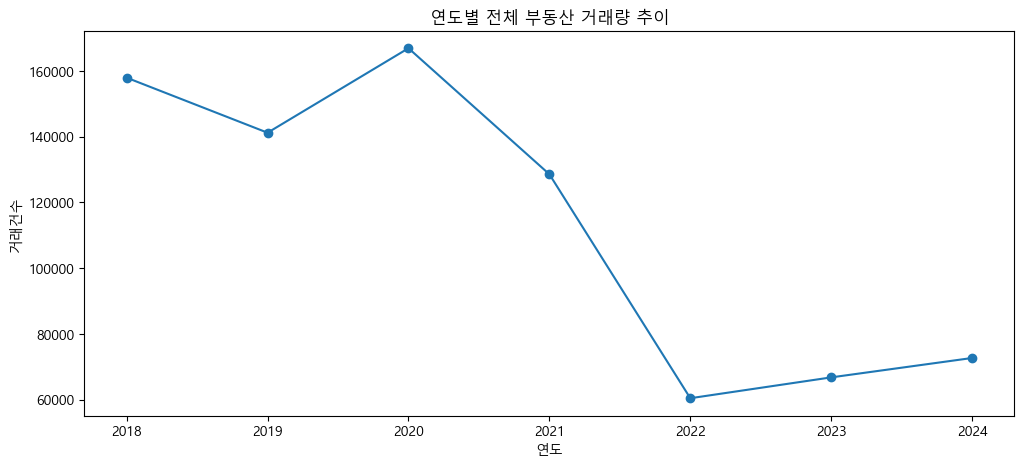

In [210]:
year_cnt = (
    dfnew.groupby("계약연도") # 연도별로 묶어라..
    .size() # 각 연도마다 행이 몇 개 있는지 세어라
    .reset_index(name="거래건수") # group by 결과는 인덱스 형태이므로 컬럼형태로 되돌림, 거래건수 컬럼이름을 "거래건수"로 붙임
)

plt.figure(figsize=(12,5)) # 캔버스 크기
plt.plot(year_cnt["계약연도"], year_cnt["거래건수"], marker="o") # plt는 꺾은선 그래프, marker="o"는 점 표시
plt.title("연도별 전체 부동산 거래량 추이")
plt.xlabel("연도")
plt.ylabel("거래건수") # 제목과 축 이름들
plt.show() # 출력

# 특정 연도 지역별 거래량 top 10

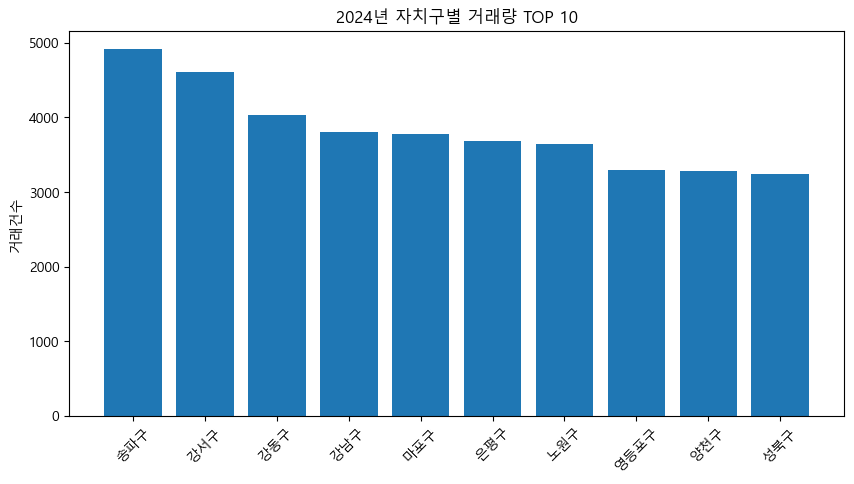

In [211]:
target_year = dfnew["계약연도"].max() 
# max면 최신연도, min이면 가장 오래된 연도, 원한다면 그냥 target_year = 2023처럼 직접 고정해도 됨

region_cnt = (
    dfnew[dfnew["계약연도"] == target_year]
    .groupby("자치구명")
    .size()
    .reset_index(name="거래건수")
    .sort_values("거래건수", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
plt.bar(region_cnt["자치구명"], region_cnt["거래건수"])
plt.title(f"{target_year}년 자치구별 거래량 TOP 10")
plt.xticks(rotation=45)
plt.ylabel("거래건수")
plt.show()


# 건물용도별 거래 비중

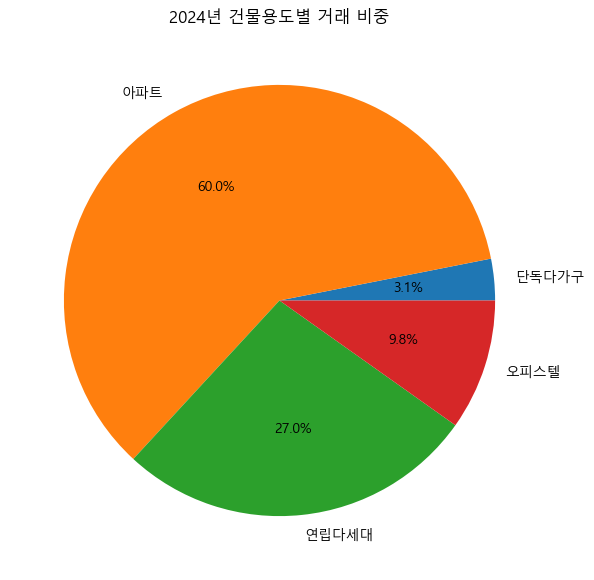

In [212]:
use_cnt = (
    dfnew[dfnew["계약연도"] == target_year]
    .groupby("건물용도")
    .size()
    .reset_index(name="거래건수")
)

plt.figure(figsize=(7,7))
plt.pie(use_cnt["거래건수"], labels=use_cnt["건물용도"], autopct="%.1f%%")
plt.title(f"{target_year}년 건물용도별 거래 비중")
plt.show()


# 지역 x 건물용도 히트맵

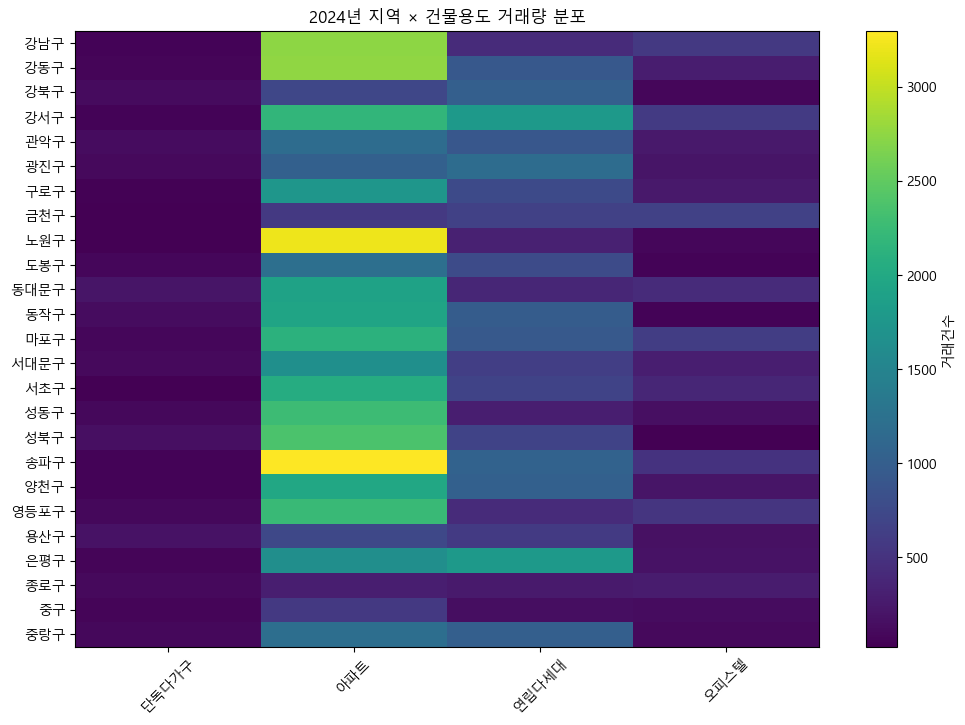

In [213]:
cross = (
    dfnew[dfnew["계약연도"] == target_year]
    .groupby(["자치구명", "건물용도"])
    .size()
    .reset_index(name="거래건수")
)

pivot = cross.pivot_table(
    index="자치구명",
    columns="건물용도",
    values="거래건수",
    fill_value=0
)

plt.figure(figsize=(12,8))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="거래건수")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title(f"{target_year}년 지역 × 건물용도 거래량 분포")
plt.show()


# 거래량 전년대비 증감률 top 지역

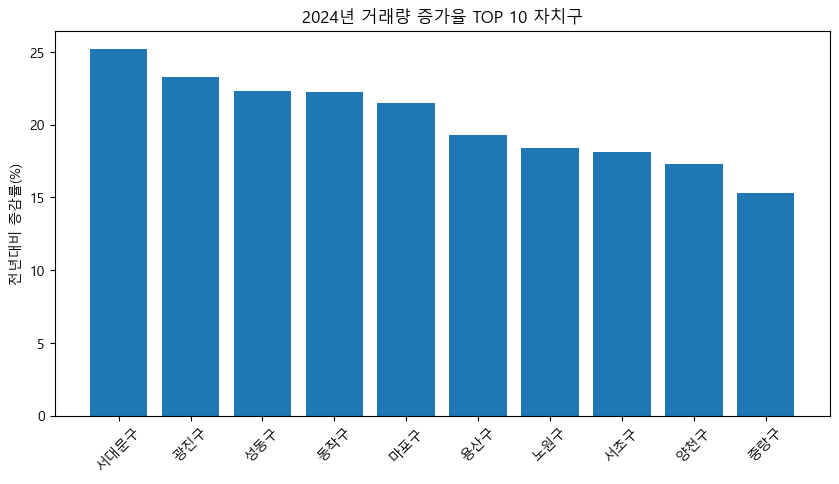

In [214]:
cnt = (
    dfnew.groupby(["자치구명", "계약연도"])
      .size()
      .reset_index(name="거래건수")
      .sort_values(["자치구명", "계약연도"])
)

cnt["YoY(%)"] = cnt.groupby("자치구명")["거래건수"].pct_change() * 100

latest = cnt[cnt["계약연도"] == target_year].dropna()

top = latest.sort_values("YoY(%)", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top["자치구명"], top["YoY(%)"])
plt.title(f"{target_year}년 거래량 증가율 TOP 10 자치구")
plt.ylabel("전년대비 증감률(%)")
plt.xticks(rotation=45)
plt.show()


# 월별 거래량

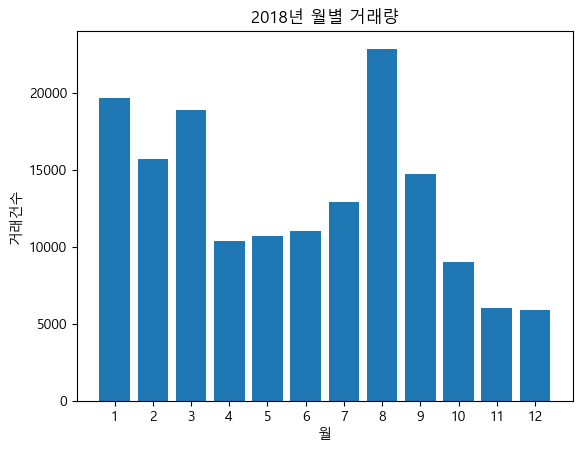

In [217]:
target_year = 2018

df_year = dfnew[dfnew["계약연도"] == target_year]

month_cnt = (
    df_year.groupby("계약월")
    .size()
    .reset_index(name="거래건수")
    .sort_values("계약월")
)

plt.Figure(figsize=(10,5))
plt.bar(month_cnt["계약월"], month_cnt["거래건수"])
plt.title(f"{target_year}년 월별 거래량")
plt.xlabel("월")
plt.ylabel("거래건수")
plt.xticks(range(1,13))
plt.show()

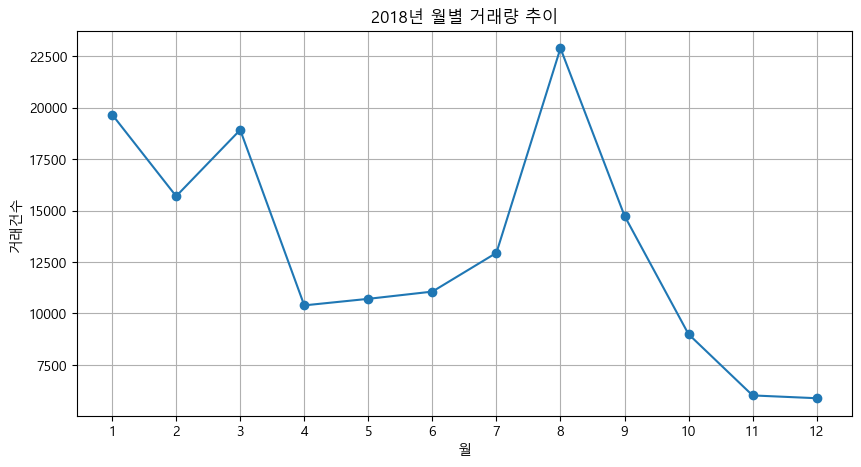

In [218]:
plt.figure(figsize=(10,5))
plt.plot(month_cnt["계약월"], month_cnt["거래건수"], marker="o")
plt.title(f"{target_year}년 월별 거래량 추이")
plt.xlabel("월")
plt.ylabel("거래건수")
plt.xticks(range(1, 13))
plt.grid()
plt.show()